# Assignment: Unsupervised Phenotype Discovery from Electronic Health Records

**Computational Medicine · Deadline: 11 Oct 2026 11:59pm · Weight: 6% of the final grade**

---

## Background

Electronic health record systems contain very large numbers of entries of the following form:

> patient 41 · type 2 diabetes · metformin

An individual entry conveys little information. In aggregate, however, such records exhibit structure: particular diagnoses and medications co-occur systematically within subsets of patients. Clinically coherent subgroups of this kind are referred to as **phenotypes**.

This assignment examines whether phenotypes can be recovered **without supervision**, that is, without labelled examples and without prior specification of the groups to be found.

## Approach

The records are represented as a third-order tensor, which is decomposed into a small number of rank-one components, each interpreted as a phenotype. This approach, **tensor factorization**, follows the Rubik method (Wang et al., KDD 2015).

The optimisation procedure of the original paper, based on ADMM with Sylvester-equation updates, lies beyond the scope of this course. A simplified implementation is used instead. It preserves each methodological component of the paper while replacing the solver with multiplicative updates.

## Tasks

Five functions, labelled `TODO 1` to `TODO 5`, implement the principal components of the method. **Each function is provided in full, with the exception of a small number of blanks marked `FILL_IN`.** Each blank must be replaced with an appropriate value: either a numerical constant, such as `0` or `1`, or the name of an existing variable, such as `gamma` or `bias`. No additional lines of code are required.


Each blank corresponds to a specific methodological decision, and the adjacent comment states the question that determines its value. Every function is accompanied by an explanation of its purpose and by a set of automated tests.

The tests compare outputs against values derived analytically and are independent of any reference implementation; a function that passes its tests is therefore correct. A test executed while a blank remains unfilled reports the outstanding `FILL_IN`. Overall progress may be checked at any point by executing `check_all()`.

Short **concept questions** are distributed throughout the notebook. Each is answered by executing a statement of the form `concept("q1", "b")`, which returns immediate feedback.

## Structure

| Part | Content | Tasks |
|---|---|---|
| 1 | Tensor representation and CP decomposition | |
| 2 | Synthetic records with known ground truth | |
| 3 | Standard non-negative factorization and its limitations | TODO 1–4 |
| 4 | Separation of the population baseline | TODO 5 |
| 5 | Sparsity and interpretability | |
| 6 | Diversity of phenotypes | applies TODO 4 |
| 7 | Robustness to missing records | |
| 8 | Annotation of phenotypes by a language model | |
| 9 | Written questions | |

## Use of synthetic data

The records used in this assignment are synthetic by design. In real clinical data the true phenotypic structure is unknown, and the quality of a recovered phenotype can be assessed only by expert judgement; the original study required blinded review by three physicians for this reason. Planting known phenotypes in synthetic data permits exact, quantitative evaluation of recovery.

### Prerequisites

A GPU is required only for Part 8. It is nonetheless advisable to select one at the outset: **Runtime → Change runtime type → T4 GPU**.

---
# 1. Tensor representation

A matrix is a two-dimensional array indexed by rows and columns. A tensor generalises this concept to an arbitrary number of dimensions. The number of indices required to identify a single entry is the **order** of the tensor.

Each record specifies three quantities: a patient, a diagnosis and a medication. The records are therefore represented naturally as a third-order tensor. Each dimension is termed a **mode**; the three modes here correspond to patients, diagnoses and medications.

The cell below defines the plotting functions used throughout the notebook and produces the first figure.

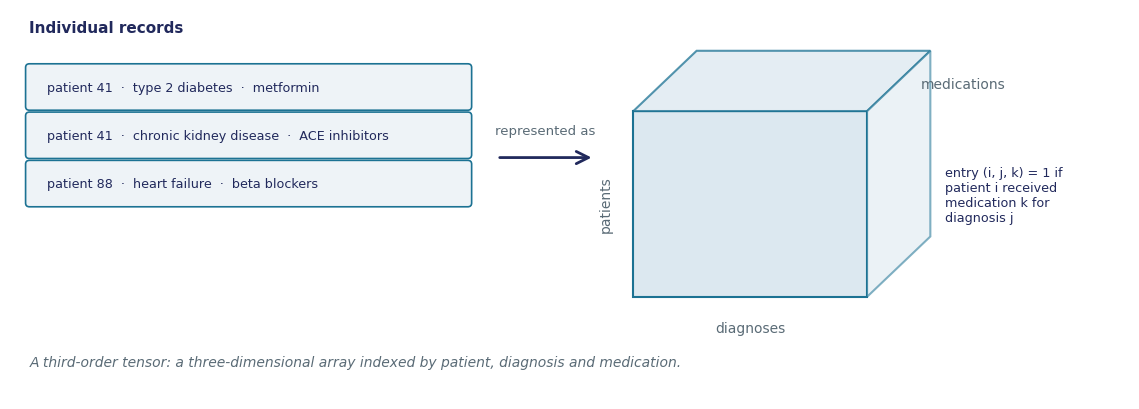

In [ ]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Polygon

INK, MUTED = "#21295C", "#5A6B76"
TEAL, AMBER, GREEN, RED = "#1C7293", "#C77D1A", "#2E7D5B", "#B3261E"


def _cube(ax, x, y, w, h, d, fc, ec, alpha=1.0, lw=1.5):
    ax.add_patch(Polygon([(x, y), (x+w, y), (x+w, y+h), (x, y+h)],
                         fc=fc, ec=ec, lw=lw, alpha=alpha))
    ax.add_patch(Polygon([(x, y+h), (x+w, y+h), (x+w+d, y+h+d), (x+d, y+h+d)],
                         fc=fc, ec=ec, lw=lw, alpha=alpha*0.75))
    ax.add_patch(Polygon([(x+w, y), (x+w+d, y+d), (x+w+d, y+h+d), (x+w, y+h)],
                         fc=fc, ec=ec, lw=lw, alpha=alpha*0.55))


def figure_what_is_a_tensor():
    fig, ax = plt.subplots(figsize=(11.5, 4.2))
    ax.set_xlim(0, 11.5); ax.set_ylim(0, 4.2); ax.axis("off")

    ax.text(0.2, 3.95, "Individual records", fontsize=11,
            fontweight="bold", color=INK)
    rows = ["patient 41  ·  type 2 diabetes  ·  metformin",
            "patient 41  ·  chronic kidney disease  ·  ACE inhibitors",
            "patient 88  ·  heart failure  ·  beta blockers"]
    for i, r in enumerate(rows):
        ax.add_patch(FancyBboxPatch((0.2, 3.15 - i*0.52), 4.5, 0.42,
                     boxstyle="round,pad=0.04", fc="#EEF3F7", ec=TEAL, lw=1.2))
        ax.text(0.38, 3.36 - i*0.52, r, fontsize=9.2, va="center", color=INK)

    ax.add_patch(FancyArrowPatch((5.0, 2.6), (6.0, 2.6), arrowstyle="->",
                 mutation_scale=22, color=INK, lw=2))
    ax.text(5.5, 2.85, "represented as", fontsize=9.5, ha="center", color=MUTED)

    _cube(ax, 6.4, 1.1, 2.4, 2.0, 0.65, "#DCE8F0", TEAL)
    ax.text(7.6, 0.72, "diagnoses", fontsize=10, ha="center", color=MUTED)
    ax.text(6.12, 2.1, "patients", fontsize=10, rotation=90, va="center",
            ha="center", color=MUTED)
    ax.text(9.35, 3.35, "medications", fontsize=10, color=MUTED)

    ax.text(9.6, 2.2, "entry (i, j, k) = 1 if\npatient i received\nmedication k for\ndiagnosis j",
            fontsize=9.2, color=INK, va="center")
    ax.text(0.2, 0.35, "A third-order tensor: a three-dimensional array indexed by patient, "
            "diagnosis and medication.",
            fontsize=10, style="italic", color=MUTED)
    fig.tight_layout()
    return fig


def figure_cp_decomposition():
    fig, ax = plt.subplots(figsize=(12, 3.6))
    ax.set_xlim(0, 12); ax.set_ylim(0, 3.6); ax.axis("off")

    _cube(ax, 0.3, 1.0, 1.7, 1.5, 0.5, "#DCE8F0", TEAL)
    ax.text(1.15, 0.55, "data tensor", fontsize=10, ha="center", color=MUTED)
    ax.text(2.55, 1.85, "≈", fontsize=26, ha="center", color=INK)

    cols = ["#BFD9E8", "#A8CBDE", "#91BDD4", "#7AAFCA"]
    x = 3.2
    for i in range(4):
        ax.add_patch(FancyBboxPatch((x, 1.0), 0.22, 1.5, boxstyle="round,pad=0.02",
                     fc=cols[i], ec=TEAL, lw=1.2))
        ax.add_patch(FancyBboxPatch((x+0.30, 2.05), 0.9, 0.22,
                     boxstyle="round,pad=0.02", fc=cols[i], ec=TEAL, lw=1.2))
        ax.add_patch(FancyBboxPatch((x+0.30, 1.55), 0.72, 0.22,
                     boxstyle="round,pad=0.02", fc=cols[i], ec=TEAL, lw=1.2))
        ax.text(x + 0.72, 0.55, f"component {i+1}", fontsize=8.6,
                ha="center", color=MUTED)
        if i < 3:
            ax.text(x + 1.48, 1.85, "+", fontsize=18, ha="center", color=INK)
        x += 1.75

    ax.text(6.0, 3.30, "CP decomposition: a sum of R rank-one components",
            ha="center", fontsize=11.5, fontweight="bold", color=INK)
    ax.text(10.9, 2.16, "diagnosis vector", fontsize=8.6, color=MUTED, va="center")
    ax.text(10.9, 1.66, "medication vector", fontsize=8.6, color=MUTED, va="center")
    ax.text(10.9, 1.75 - 0.0, "", fontsize=8.6)
    ax.annotate("", xy=(10.35, 2.16), xytext=(10.85, 2.16),
                arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
    ax.annotate("", xy=(10.17, 1.66), xytext=(10.85, 1.66),
                arrowprops=dict(arrowstyle="->", color=MUTED, lw=1.2))
    ax.text(3.05, 1.75, "patient vector", fontsize=8.6, color=MUTED,
            rotation=90, ha="right", va="center")
    ax.text(6.0, 0.15, "Each component associates a set of patients with a set of diagnoses "
            "and medications, and is interpreted as a phenotype.",
            ha="center", fontsize=10, style="italic", color=MUTED)
    fig.tight_layout()
    return fig


def figure_bias_split():
    fig, ax = plt.subplots(figsize=(12, 4.0))
    ax.set_xlim(0, 12); ax.set_ylim(0, 4.0); ax.axis("off")

    _cube(ax, 0.3, 1.5, 1.5, 1.4, 0.45, "#DCE8F0", TEAL)
    ax.text(1.05, 1.1, "data tensor", fontsize=9.5, ha="center", color=MUTED)
    ax.text(2.25, 2.15, "=", fontsize=24, ha="center", color=INK)

    _cube(ax, 2.7, 1.5, 1.5, 1.4, 0.45, "#F2DFC2", AMBER)
    ax.text(3.45, 1.1, "bias tensor", fontsize=9.5, ha="center",
            color=AMBER, fontweight="bold")
    ax.text(4.65, 2.15, "+", fontsize=24, ha="center", color=INK)

    _cube(ax, 5.1, 1.5, 1.5, 1.4, 0.45, "#CFE3D6", GREEN)
    ax.text(5.85, 1.1, "interaction tensor", fontsize=9.5, ha="center",
            color=GREEN, fontweight="bold")

    ax.add_patch(FancyBboxPatch((7.2, 2.15), 4.5, 1.25,
                 boxstyle="round,pad=0.06", fc="#FDF3E3", ec=AMBER, lw=1.4))
    ax.text(7.45, 3.16, "Bias tensor: population baseline", fontsize=9.8,
            fontweight="bold", color=AMBER)
    ax.text(7.45, 2.80, "hypertension · lipid disorder · kidney disease\n"
            "statins · diuretics · calcium channel blockers",
            fontsize=8.8, color=INK, va="top")

    ax.add_patch(FancyBboxPatch((7.2, 0.55), 4.5, 1.35,
                 boxstyle="round,pad=0.06", fc="#E9F2EC", ec=GREEN, lw=1.4))
    ax.text(7.45, 1.66, "Interaction tensor: phenotypes", fontsize=9.8,
            fontweight="bold", color=GREEN)
    ax.text(7.45, 1.30, "diabetes + insulin, metformin\n"
            "heart failure + beta blockers\nlung disease + inhalers",
            fontsize=8.8, color=INK, va="top")

    ax.text(6.0, 3.72, "Decomposition into bias and interaction tensors",
            ha="center", fontsize=11.5, fontweight="bold", color=INK)
    ax.text(0.3, 0.2, "Without the bias tensor, the leading components represent the "
            "prevalent comorbidities rather than distinct phenotypes.",
            fontsize=10, style="italic", color=MUTED)
    fig.tight_layout()
    return fig


def figure_overlap(lam_curve=None):
    fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))

    ax = axes[0]; ax.set_xlim(0, 6); ax.set_ylim(0, 3.2); ax.axis("off")
    ax.text(3.0, 3.0, "Overlap between components",
            ha="center", fontsize=11, fontweight="bold", color=INK)
    from matplotlib.patches import Circle
    ax.add_patch(Circle((2.3, 1.5), 1.05, fc=RED, alpha=0.32, ec=RED, lw=1.6))
    ax.add_patch(Circle((3.5, 1.5), 1.05, fc=TEAL, alpha=0.32, ec=TEAL, lw=1.6))
    ax.text(1.55, 1.5, "component 1", fontsize=9, ha="center", color=INK)
    ax.text(4.25, 1.5, "component 2", fontsize=9, ha="center", color=INK)
    ax.text(2.9, 1.5, "shared", fontsize=8.5, ha="center", color=INK,
            fontweight="bold")
    ax.text(3.0, 0.15, "Components sharing most of their entries\n"
            "do not represent distinct findings.",
            ha="center", fontsize=9.3, style="italic", color=MUTED)

    ax = axes[1]
    if lam_curve is None:
        lam_curve = [(0,0.152),(0.5,0.141),(1,0.139),(2,0.136),
                     (5,0.129),(10,0.119),(20,0.089),(50,0.073)]
    xs = [l for l, _ in lam_curve]; ys = [o for _, o in lam_curve]
    ax.plot(xs, ys, "o-", color=TEAL, lw=2, ms=6)
    ax.set_xscale("symlog", linthresh=1)
    ax.set_xlabel("weight of the diversity penalty (lambda)", fontsize=9.5)
    ax.set_ylabel("AvgOverlap", fontsize=9.5)
    ax.set_title("AvgOverlap as a function of lambda", fontsize=11,
                 fontweight="bold", color=INK)
    ax.grid(alpha=0.25)
    ax.tick_params(labelsize=8.5)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    fig.tight_layout()
    return fig

plt.close("all")
figure_what_is_a_tensor()
plt.show()

### Additional plotting functions

The following cell defines the remaining plotting functions. It should be executed once; its contents need not be examined.

In [ ]:
# ===========================================================================
#  Plotting functions for the figures in this notebook.
#  This cell need not be examined.
# ===========================================================================
import numpy as np
import matplotlib.pyplot as plt

_INK, _TEAL, _AMBER = "#21295C", "#1C7293", "#C77D1A"
_GREEN, _RED, _MUTED = "#2E7D5B", "#B3261E", "#5A6B76"
_GROUP_COLOURS = {"diabetes": "#1C7293", "heart failure": "#B3261E",
                  "lung disease": "#2E7D5B", "mental health": "#7A4FA3"}


def _tidy(ax):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)


def show_records(X, membership, labels):
    """Recorded diagnoses for every patient, ordered by phenotype."""
    first = [m[0] for m in membership]
    order = sorted(range(len(first)), key=lambda i: list(_GROUP_COLOURS).index(first[i]))
    M = X.sum(axis=2)[order]                    # how many drugs per (patient, diagnosis)

    fig, (side, ax) = plt.subplots(1, 2, figsize=(11, 5.6),
                                   gridspec_kw={"width_ratios": [0.4, 12]})
    ax.imshow(M > 0, aspect="auto", cmap="Blues", interpolation="nearest")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=55, ha="right", fontsize=8.5)
    ax.set_yticks([])
    ax.set_title("Recorded diagnoses by patient (rows) and diagnosis (columns)",
                 fontsize=11, color=_INK, loc="left", pad=22)

    strip = np.array([[list(_GROUP_COLOURS).index(first[i])] for i in order])
    from matplotlib.colors import ListedColormap
    side.imshow(strip, aspect="auto", cmap=ListedColormap(list(_GROUP_COLOURS.values())))
    side.set_xticks([]); side.set_yticks([])
    side.set_ylabel("patients, ordered by phenotype", fontsize=9, color=_MUTED)

    handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in _GROUP_COLOURS.values()]
    ax.legend(handles, list(_GROUP_COLOURS), loc="upper left", bbox_to_anchor=(1.01, 1),
              fontsize=8.5, title="phenotype", title_fontsize=8.5, frameon=False)
    # the first four columns are the baseline: point at them
    ax.annotate("", xy=(-0.45, -0.02), xytext=(3.45, -0.02), xycoords=("data", "axes fraction"),
                textcoords=("data", "axes fraction"),
                arrowprops=dict(arrowstyle="-", color=_AMBER, lw=3))
    ax.text(1.5, 1.035, "population baseline",
            transform=ax.get_xaxis_transform(), ha="center", fontsize=9,
            color=_AMBER, fontweight="bold")
    fig.tight_layout()
    return fig


def compare_pieces(plain_dx, bias_dx, inter_dx, labels, gamma=0.15):
    """Diagnosis weights of each component, without and with the bias tensor."""
    def draw(ax, vec, title, colour):
        v = vec / (vec.max() + 1e-12)
        keep = v >= gamma
        idx = np.argsort(-v)[:6][::-1]
        ax.barh(range(len(idx)), v[idx],
                color=[colour if keep[i] else "#D5DCE2" for i in idx])
        ax.set_yticks(range(len(idx)))
        ax.set_yticklabels([labels[i] for i in idx], fontsize=7.5)
        ax.set_xlim(0, 1.05); ax.set_xticks([])
        ax.set_title(title, fontsize=9.5, color=colour, fontweight="bold")
        _tidy(ax)

    R = plain_dx.shape[1]
    base_items = set(np.argsort(-bias_dx[:, 0])[:4])
    fig, axes = plt.subplots(2, R + 1, figsize=(14, 5.4))
    axes[0, 0].axis("off")
    axes[0, 0].text(0.5, 0.5, "Without\nbias tensor", ha="center", va="center",
                    fontsize=12, color=_RED, fontweight="bold")
    for r in range(R):
        v = plain_dx[:, r] / (plain_dx[:, r].max() + 1e-12)
        kept = set(np.where(v >= gamma)[0])
        wasted = len(kept & base_items) >= 3
        draw(axes[0, r + 1], plain_dx[:, r],
             f"component {r}: baseline" if wasted else f"component {r}",
             _RED if wasted else _MUTED)
    draw(axes[1, 0], bias_dx[:, 0], "bias tensor", _AMBER)
    for r in range(R):
        draw(axes[1, r + 1], inter_dx[:, r], f"component {r}", _GREEN)
    fig.suptitle("Upper row: standard factorization, one component absorbs the baseline.   "
                 "Lower row: with the bias tensor, every component is a phenotype.",
                 fontsize=11, color=_INK, x=0.02, ha="left")
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    return fig


def show_baseline_rounds(X, R, labels, rounds=6, seed=0):
    """Weights of selected diagnoses in the bias tensor across iterations."""
    watch = {"hypertension": _AMBER, "chronic kidney disease": _MUTED,
             "type 2 diabetes": _TEAL, "heart failure": _RED}
    idx = {w: labels.index(w) for w in watch}
    hist = {w: [] for w in watch}

    def record(b):
        v = b[1][:, 0] / b[1][:, 0].max()
        for w in watch:
            hist[w].append(v[idx[w]])

    bias = ncp(X, 1, n_iter=120, seed=seed); record(bias)
    for _ in range(rounds):
        left = np.maximum(X - reconstruct(bias), 0)
        inter = ncp(left, R, n_iter=120, seed=seed)
        left = np.maximum(X - reconstruct(inter), 0)
        bias = ncp(left, 1, n_iter=120, seed=seed); record(bias)

    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 3.8))
    for w, c in watch.items():
        if w in ("hypertension", "chronic kidney disease"):
            a1.plot(hist[w], "o-", color=c, lw=2, label=w)
        else:
            a2.plot(hist[w], "o-", color=c, lw=2, label=w)
    a1.set_title("Baseline conditions: weights retained", fontsize=10.5, color=_INK)
    a2.set_title("Phenotype diagnoses: weights reduced", fontsize=10.5, color=_INK)
    for a in (a1, a2):
        a.set_xlabel("iteration (0 = initial estimate)")
        a.set_ylabel("weight in bias tensor")
        a.legend(fontsize=8.5); a.grid(alpha=0.25); _tidy(a)
    a1.set_ylim(0, 1.08); a2.set_ylim(0, None)
    fig.tight_layout()
    return fig


def show_cutoff(vec, labels, gammas=(0.15, 0.5)):
    """Effect of the sparsity threshold on one component."""
    v = vec / (vec.max() + 1e-12)
    idx = np.argsort(-v)[:9][::-1]
    fig, axes = plt.subplots(1, len(gammas), figsize=(12, 3.8), sharey=True)
    for ax, g in zip(np.atleast_1d(axes), gammas):
        keep = v[idx] >= g
        ax.barh(range(len(idx)), v[idx],
                color=[_TEAL if k else "#D5DCE2" for k in keep])
        ax.axvline(g, color=_AMBER, ls="--", lw=2)
        ax.text(g + 0.02, len(idx) - 0.6, f"threshold (gamma = {g})",
                color=_AMBER, fontsize=9)
        ax.set_yticks(range(len(idx)))
        ax.set_yticklabels([labels[i] for i in idx], fontsize=8.5)
        ax.set_xlim(0, 1.15)
        ax.set_title(f"{int(keep.sum())} diagnoses retained", fontsize=10.5, color=_INK)
        ax.set_xlabel("weight relative to maximum")
        _tidy(ax)
    fig.tight_layout()
    return fig


def show_similarity(F_before, F_after, lam):
    """Pairwise cosine similarity between components."""
    def sim(F):
        N = F / (np.linalg.norm(F, axis=0, keepdims=True) + 1e-12)
        return N.T @ N
    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))
    for ax, F, t in zip(axes, (F_before, F_after),
                        ("lambda = 0", f"lambda = {lam}")):
        S = sim(F)
        im = ax.imshow(S, cmap="Oranges", vmin=0, vmax=1)
        R = S.shape[0]
        for a in range(R):
            for b in range(R):
                ax.text(b, a, f"{S[a, b]:.2f}", ha="center", va="center", fontsize=8,
                        color="white" if S[a, b] > 0.6 else _INK)
        ax.set_xticks(range(R)); ax.set_yticks(range(R))
        ax.set_xlabel("component"); ax.set_ylabel("component")
        ax.set_title(t, fontsize=10.5, color=_INK)
    fig.suptitle("Pairwise cosine similarity between components. "
                 "Diagonal entries equal 1 by definition.", fontsize=10.5, color=_INK, x=0.02, ha="left")
    fig.tight_layout(rect=(0, 0, 1, 0.92))
    return fig


def show_missing(points):
    """Phenotypes recovered under random deletion. points = [(fraction, [n, ...]), ...]"""
    xs = [int(p * 100) for p, _ in points]
    mean = [np.mean(n) for _, n in points]
    lo = [min(n) for _, n in points]; hi = [max(n) for _, n in points]
    fig, ax = plt.subplots(figsize=(7.5, 3.6))
    ax.fill_between(xs, lo, hi, color=_TEAL, alpha=0.15, label="range over replicates")
    ax.plot(xs, mean, "o-", color=_TEAL, lw=2.4, ms=8, label="mean over replicates")
    ax.legend(fontsize=8.5, loc="lower left")
    ax.axhline(4, color=_GREEN, ls=":", lw=1.5)
    ax.text(xs[-1], 4.08, "all four phenotypes", color=_GREEN, fontsize=9, ha="right")
    ax.set_ylim(0, 4.6); ax.set_yticks(range(5))
    ax.set_xlabel("records deleted (%)"); ax.set_ylabel("phenotypes recovered")
    ax.set_title("Phenotype recovery under random deletion of records",
                 fontsize=11, color=_INK)
    ax.grid(alpha=0.25); _tidy(ax)
    fig.tight_layout()
    return fig

print("Plotting functions loaded.")

### Automated tests

The following cell defines the tests for the five functions and the checker for the concept questions. It should be executed once; its contents need not be examined.

In [ ]:

# ============================================================================
#  Self-check.  You do not need to read this cell.
#
#  Every number in here was worked out by hand, so these tests do not depend
#  on any answer key. If your function passes, it is right.
#
#  Run  check_all()  at any time to see where you are.
# ============================================================================
import numpy as np


def _ok(test, label, note=""):
    try:
        good = bool(test() if callable(test) else test)
        why = note
    except NotImplementedError:
        good, why = False, "the function has not yet been completed"
    except NameError as e:
        if "FILL_IN" in str(e):
            good, why = False, "a FILL_IN blank remains to be completed in this function"
        else:
            good, why = False, f"NameError: {e}"
    except Exception as e:
        good, why = False, f"{type(e).__name__}: {e}"
    print(f"  {'PASS' if good else 'FAIL'}  {label}" +
          (f"\n            -> {why}" if why and not good else ""))
    return good


def test_reconstruct():
    print("TODO 1  reconstruct")
    a = np.array([1.0, 0.0, 2.0])
    b = np.array([0.0, 3.0, 1.0, 0.0])
    c = np.array([2.0, 5.0])
    one = lambda: reconstruct([a[:, None], b[:, None], c[:, None]])

    A = np.array([[1.0, 0.0], [0.0, 1.0]])
    B = np.array([[2.0, 0.0], [0.0, 3.0]])
    C = np.array([[1.0, 0.0], [0.0, 1.0]])
    two = lambda: reconstruct([A, B, C])

    return all([
        _ok(lambda: one().shape == (3, 4, 2), "the reconstructed tensor has shape (3, 4, 2)"),
        _ok(lambda: np.isclose(one()[2, 1, 0], 12.0),
            "T[2,1,0] = a[2] * b[1] * c[0] = 2 * 3 * 2 = 12"),
        _ok(lambda: np.isclose(one()[0, 2, 1], 5.0), "T[0,2,1] = 1 * 1 * 5 = 5"),
        _ok(lambda: np.isclose(one()[1, 1, 1], 0.0),
            "a[1] = 0, so every entry of the corresponding slice is 0"),
        _ok(lambda: np.isclose(two()[0, 0, 0], 2.0),
            "with R = 2 the components are summed; component 0 contributes 2 here"),
        _ok(lambda: np.isclose(two()[1, 1, 1], 3.0), "component 1 contributes 3 here"),
        _ok(lambda: np.isclose(two()[0, 1, 0], 0.0),
            "each component contributes only to its own entries"),
    ])


def test_sparsify():
    print("TODO 2  sparsify and top_items")
    v = lambda: np.array([1.0, 0.5, 0.05, 0.0, 0.2])
    labels = ["a", "b", "c", "d", "e"]

    def untouched():
        x = v()
        sparsify(x, 0.15)
        return np.allclose(x, [1.0, 0.5, 0.05, 0.0, 0.2])

    return all([
        _ok(lambda: np.allclose(sparsify(v(), 0.15), [1.0, 0.5, 0.0, 0.0, 0.2]),
            "the threshold is 0.15 times the maximum (here 0.15), so only the entry 0.05 is removed"),
        _ok(lambda: np.allclose(sparsify(v() * 100, 0.15),
                                [100.0, 50.0, 0.0, 0.0, 20.0]),
            "scaling the vector by 100 leaves the pattern of zeros unchanged (the threshold is relative)"),
        _ok(lambda: np.allclose(sparsify(v(), 0.0), v()), "gamma = 0 retains every entry"),
        _ok(lambda: (sparsify(v(), 0.9) > 0).sum() == 1,
            "gamma = 0.9 retains only the largest entry"),
        _ok(untouched, "sparsify does not modify its input array"),
        _ok(lambda: list(top_items(v(), labels, 0.15)) == ["a", "b", "e"],
            "top_items returns only the retained labels, in descending order of weight; "
            "entries set to zero by sparsify are excluded"),
        _ok(lambda: len(list(top_items(v(), labels, 0.15))) == 3,
            "three labels are returned here, not all five"),
        _ok(lambda: list(top_items(v(), labels, 0.9)) == ["a"],
            "top_items applies the threshold gamma"),
    ])


def test_avg_overlap():
    print("TODO 3  avg_overlap")
    same   = np.array([[1.0, 1.0], [0.0, 0.0], [0.0, 0.0]])
    apart  = np.array([[1.0, 0.0], [0.0, 1.0], [0.0, 0.0]])
    scaled = np.array([[1.0, 50.0], [0.0, 0.0], [0.0, 0.0]])
    three  = np.array([[1.0, 1.0, 0.0], [0.0, 0.0, 1.0], [0.0, 0.0, 0.0]])

    return all([
        _ok(lambda: np.isclose(avg_overlap(same), 1.0),
            "two identical columns yield an overlap of 1.0"),
        _ok(lambda: np.isclose(avg_overlap(apart), 0.0),
            "two columns with no shared entries yield an overlap of 0.0"),
        _ok(lambda: np.isclose(avg_overlap(scaled), 1.0),
            "the result depends on direction only, not magnitude (columns are normalised)"),
        _ok(lambda: np.isclose(avg_overlap(three), 1 / 3),
            "the mean is taken over all pairs: here 1, 0 and 0, giving 0.333"),
    ])


def test_overlap_penalty():
    print("TODO 4  overlap_penalty")
    same  = np.array([[1.0, 1.0], [0.0, 0.0]])
    apart = np.array([[1.0, 0.0], [0.0, 1.0]])

    return all([
        _ok(lambda: overlap_penalty(apart, 5.0).shape == apart.shape,
            "the penalty has the same shape as the factor matrix"),
        _ok(lambda: np.allclose(overlap_penalty(apart, 5.0), 0.0),
            "columns with no shared entries incur no penalty"),
        _ok(lambda: (overlap_penalty(same, 5.0) > 0).any(),
            "overlapping columns incur a positive penalty"),
        _ok(lambda: np.allclose(overlap_penalty(same, 0.0), 0.0),
            "lam = 0 removes the penalty"),
        _ok(lambda: np.allclose(overlap_penalty(same, 10.0),
                                2 * overlap_penalty(same, 5.0)),
            "the penalty scales linearly with lam"),
        _ok(lambda: np.allclose(np.diag(same.T @ same * (1 - np.eye(2))), 0),
            "the diagonal is excluded, since a column is not penalised for overlap with itself"),
    ])


def test_fit():
    print("TODO 5  fit_bias_and_interaction")
    try:
        bias, inter = fit_bias_and_interaction(X, 4, seed=0)
    except NotImplementedError:
        return _ok(False, "the function executes", "the function has not yet been completed")
    except NameError as e:
        msg = ("a FILL_IN blank remains to be completed in this function"
               if "FILL_IN" in str(e) else f"NameError: {e}")
        return _ok(False, "the function executes", msg)
    except Exception as e:
        return _ok(False, "the function executes", f"{type(e).__name__}: {e}")

    base = set(top_items(bias[1][:, 0], DIAGNOSES, 0.15))
    common = {"hypertension", "lipid disorder", "chronic kidney disease", "anaemia"}
    found = {m[1] for m in match_to_truth(inter[1], inter[2]) if m[2] >= 0.7}

    return all([
        _ok(lambda: len(bias) == 3 and bias[1].shape[1] == 1,
            "the bias tensor is rank-one: each of its factor matrices has one column"),
        _ok(lambda: inter[1].shape[1] == 4, "the interaction tensor has R components"),
        _ok(lambda: len(base & common) >= 3,
            f"the bias tensor contains the baseline conditions ({len(base & common)} of 4)",
            f"it currently contains {sorted(base)}"),
        _ok(lambda: "type 2 diabetes" not in base,
            "the bias tensor represents the baseline, not a phenotype"),
        _ok(lambda: len(found) >= 3,
            f"at least 3 of the 4 planted phenotypes are recovered ({len(found)} found)",
            f"found {sorted(found)}"),
    ])


def check_all():
    res = {"TODO 1": test_reconstruct(), "TODO 2": test_sparsify(),
           "TODO 3": test_avg_overlap(), "TODO 4": test_overlap_penalty(),
           "TODO 5": test_fit()}
    print("\n" + "=" * 62)
    for k, v in res.items():
        print(f"  {k}: {'complete' if v else 'incomplete'}")
    n = sum(res.values())
    print(f"\n  {n} of {len(res)} finished.")
    print("  All functions are complete. Proceed with the notebook." if n == len(res)
          else "  Correct the failures above, then execute this cell again.")
    return n == len(res)


# ----------------------------------------------------------------- concepts
_ANSWERS = {
    "q1": ("b", "300 \u00d7 16 \u00d7 14 = 67,200 entries: one for each combination "
                "of patient, diagnosis and medication."),
    "q2": ("c", "The baseline conditions are present in almost every patient and "
                "therefore constitute the dominant pattern, to which the "
                "decomposition allocates a component."),
    "q3": ("a", "A feature shared by every patient belongs to the bias tensor; a "
                "phenotype represents what distinguishes a subgroup from the population."),
    "q4": ("c", "With gamma = 1.0 only entries equal to the maximum are retained, "
                "so each vector is reduced to a single entry."),
    "q5": ("b", "Identical vectors have the same direction, so their cosine "
                "similarity is 1.0."),
    "q6": ("c", "A low overlap score does not establish correctness: phenotypes may "
                "genuinely share features, and enforcing separation can conceal "
                "true structure."),
    "q7": ("b", "A small phenotype is supported by fewer records, so the removal of "
                "the same proportion leaves less evidence for it."),
}


def concept(qid, answer):
    """Check a concept question. Example:  concept("q1", "b")"""
    key = str(qid).lower().strip()
    if key not in _ANSWERS:
        print(f"  No concept question is named {qid!r}.")
        return False
    want, why = _ANSWERS[key]
    got = str(answer).lower().strip()
    if got == want:
        print(f"  {key}: Correct. {why}")
        return True
    print(f"  {key}: Incorrect. Reconsider the question and try again.")
    return False

print("Tests loaded. Use check_all() and concept().")

Execute the cell below. At this stage every test is expected to fail, since no blanks have yet been completed.

In [ ]:
check_all()

Entry $(i, j, k)$ of the tensor equals 1 if patient $i$ received medication $k$ for diagnosis $j$, and 0 otherwise. Because no patient presents with every condition, the tensor is highly sparse.

### Decomposition into rank-one components

A **rank-one tensor** is the outer product of one vector per mode, $\mathbf{a} \otimes \mathbf{b} \otimes \mathbf{c}$, with entries $T(i,j,k) = a_i \, b_j \, c_k$. The **CP decomposition** approximates the data tensor as a sum of $R$ such components:

$$\mathcal{X} \;\approx\; \sum_{r=1}^{R} \mathbf{a}_r \otimes \mathbf{b}_r \otimes \mathbf{c}_r$$

Each component comprises a patient vector, a diagnosis vector and a medication vector, and is interpreted as one phenotype. The number of components $R$ is specified in advance, analogously to the number of clusters in k-means.

The cell below illustrates the decomposition.

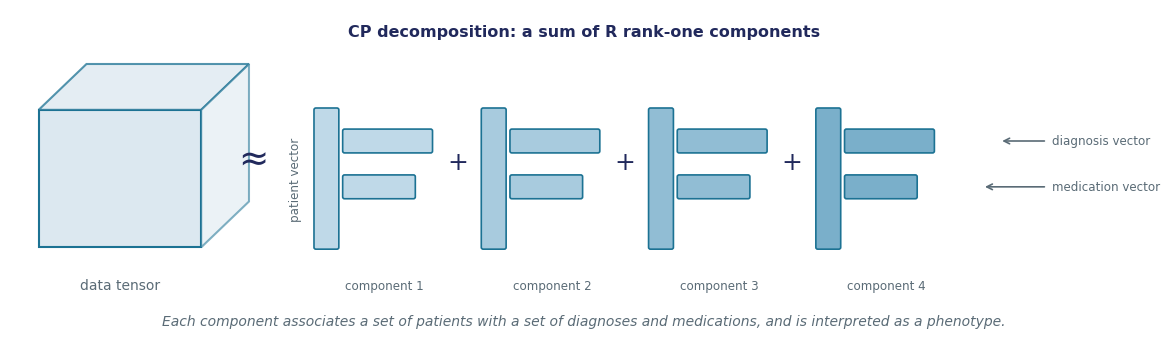

In [ ]:
figure_cp_decomposition()
plt.show()

A phenotype is therefore defined by three vectors that are interpreted jointly. A component that assigns high weight to *type 2 diabetes* and *diabetic neuropathy* in its diagnosis vector, and to *insulin* and *metformin* in its medication vector, may be interpreted as a diabetes phenotype. This association is not specified in advance; it emerges because these diagnoses and medications co-occur in the records.

Arranging the $R$ vectors of a single mode as columns yields a **factor matrix**. The decomposition is therefore described by three factor matrices, $A$, $B$ and $C$.

`TODO 1`, located in Part 3, implements the reconstruction of the tensor from its three factor matrices.

---
# 2. Synthetic records with known ground truth

The dataset comprises 300 synthetic patients.

Every patient exhibits part of a **population baseline**, consisting of conditions that are highly prevalent among hospital attendees: hypertension, lipid disorder, chronic kidney disease and anaemia, treated with statins, loop diuretics and calcium channel blockers.

In addition, each patient belongs to one or two of **four planted phenotypes**, which constitute the ground truth against which recovery is evaluated.

Two of the phenotypes share features intentionally. Chronic kidney disease and ACE inhibitors occur in both the diabetes and the heart failure phenotypes, as they do in clinical practice. This overlap becomes relevant in Part 6.

The cell below defines the diagnoses, the medications, the baseline and the four planted phenotypes. These definitions constitute the ground truth. They are disclosed because the purpose of the assignment is to evaluate whether the method recovers them without access to this information.

In [ ]:
DIAGNOSES = [
 "hypertension","lipid disorder","chronic kidney disease","anaemia",      # baseline
 "type 2 diabetes","diabetic neuropathy","diabetic retinopathy",          # P1
 "heart failure","atrial fibrillation","ischaemic heart disease",         # P2
 "COPD","asthma","chest infection",                                       # P3
 "depression","anxiety","insomnia",                                       # P4
]
MEDICATIONS = [
 "statins","loop diuretics","calcium channel blockers",                   # baseline
 "insulin","metformin","SGLT2 inhibitors",                                # P1
 "beta blockers","ACE inhibitors","anticoagulants",                       # P2
 "inhaled steroids","bronchodilators","antibiotics",                      # P3
 "SSRIs","benzodiazepines",                                               # P4
]
DX = {d: i for i, d in enumerate(DIAGNOSES)}
RX = {m: i for i, m in enumerate(MEDICATIONS)}

BASELINE = {"dx": ["hypertension","lipid disorder","chronic kidney disease","anaemia"],
            "rx": ["statins","loop diuretics","calcium channel blockers"]}

TRUE_PHENOTYPES = {
 # Note the deliberate sharing: chronic kidney disease and ACE inhibitors
 # appear in BOTH the diabetes and the heart failure phenotype, exactly as
 # they would in real data.
 "diabetes":      {"dx": ["type 2 diabetes","diabetic neuropathy","chronic kidney disease"],
                   "rx": ["insulin","metformin","ACE inhibitors"]},
 "heart failure": {"dx": ["heart failure","atrial fibrillation","chronic kidney disease"],
                   "rx": ["beta blockers","ACE inhibitors","anticoagulants"]},
 "lung disease":  {"dx": ["COPD","asthma","chest infection"],
                   "rx": ["inhaled steroids","bronchodilators","antibiotics"]},
 "mental health": {"dx": ["depression","anxiety","insomnia"],
                   "rx": ["SSRIs","benzodiazepines"]},
}

### Loading the records

Two data files accompany this assignment:

| File | Contents |
|---|---|
| `ehr_records.csv` | One row per (patient, diagnosis, medication) triple; 5,817 rows |
| `patient_groups.csv` | The phenotype membership of each patient; 300 rows |

In Colab, open the file panel (the folder icon in the left margin) and upload both files. If either file is absent, the cell below prompts for it.

All students use identical data, so that results are directly comparable across submissions.

The records are provided in long format, as they would be exported from a clinical information system. The cell below converts them into the three-mode tensor.

The records are synthetic and contain no information relating to real patients.

In [ ]:
# ===========================================================================
#  THE DATASET
#
#  Two files come with this assignment:
#
#     ehr_records.csv     one row per (patient, diagnosis, medication)
#     patient_groups.csv  which group each patient really belongs to
#
#  In Colab, click the folder icon on the left and drag both files in.
#  If you forget, the cell will ask you to choose them.
#
#  The records are invented. No real patient is
#  involved.
# ===========================================================================
import os
import numpy as np
import pandas as pd


def _find(filename):
    """Return the path to a data file, asking for an upload if it is missing."""
    for folder in (".", "data", "/content", "/content/data"):
        path = os.path.join(folder, filename)
        if os.path.exists(path):
            return path
    try:                                   # running in Colab
        from google.colab import files
        print(f"{filename} was not found. Please select the file.")
        files.upload()
        if os.path.exists(filename):
            return filename
    except ImportError:
        pass
    raise FileNotFoundError(
        f"Could not find {filename}. Put it next to this notebook, or drag it "
        f"into the file panel on the left in Colab, then run this cell again.")


# ---- read the two files ---------------------------------------------------
records = pd.read_csv(_find("ehr_records.csv"))
groups = pd.read_csv(_find("patient_groups.csv"))

membership = [g.split("; ") for g in groups.sort_values("patient_id").groups]

# ---- turn the rows into the three-sided box -------------------------------
DX = {d: i for i, d in enumerate(DIAGNOSES)}
RX = {m: i for i, m in enumerate(MEDICATIONS)}

N_PATIENTS = int(records.patient_id.max()) + 1
X = np.zeros((N_PATIENTS, len(DIAGNOSES), len(MEDICATIONS)))
for row in records.itertuples():
    X[row.patient_id, DX[row.diagnosis], RX[row.medication]] = 1.0

print("records loaded           :", len(records))
print("tensor shape             :", X.shape, " (patients, diagnoses, medications)")
print("density                  :", f"{X.mean():.1%} of entries are non-zero")
print()
print("first five records:")
print(records.head().to_string(index=False))
print()
print("phenotype membership of the first five patients:")
for i in range(5):
    print("  patient", i, "->", membership[i])


### Visualisation of the dataset

The following figure presents the data as a matrix of patients (rows) against diagnoses (columns), in which an entry is shaded where the diagnosis is recorded. Patients are ordered by phenotype membership, as indicated by the coloured strip on the left.

The four leftmost columns are populated for almost every patient. These columns constitute the population baseline, which is therefore apparent before any analysis is performed. The blocks to the right correspond to the four phenotypes, each characterised by its own set of diagnoses.

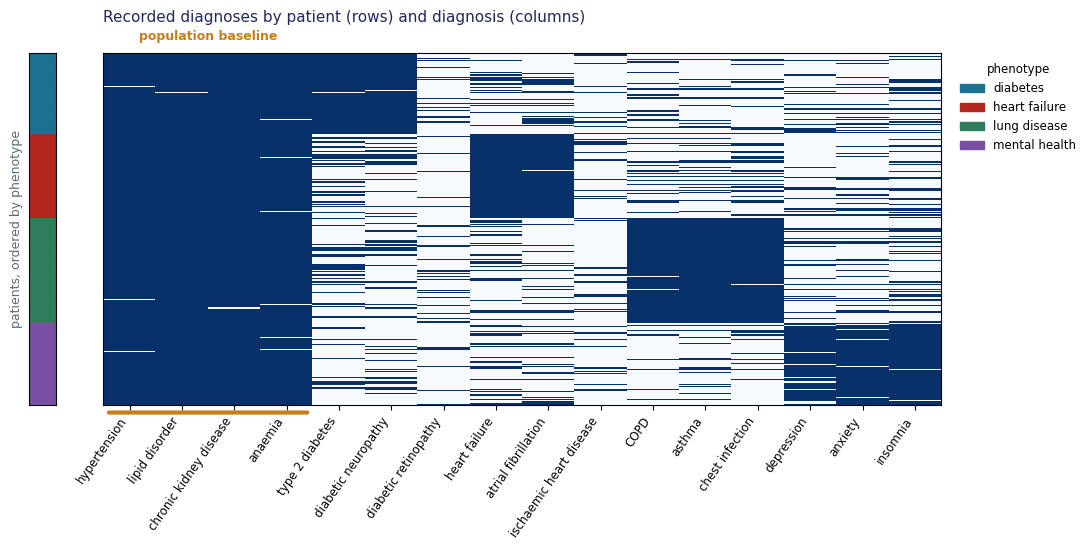

In [ ]:
show_records(X, membership, DIAGNOSES)
plt.show()

### Concept question 1

The tensor comprises 300 patients, 16 diagnoses and 14 medications.

**What is the total number of entries in the tensor?**

- **a)** 300 + 16 + 14
- **b)** 300 × 16 × 14
- **c)** 300 × 16

Record the answer in the cell below by replacing the question mark with the selected letter, then execute the cell.

In [ ]:
concept("q1", "?")

---
# 3. Standard non-negative factorization and its limitations

This part decomposes the tensor into four components and examines the content of each.

**This part contains `TODO 1` to `TODO 4`.**

The method employed is **non-negative CP decomposition**, in which every entry of every factor matrix is constrained to be non-negative. The constraint is motivated by interpretability: a phenotype should be characterised by the presence of diagnoses and medications, and a negative loading has no clinical meaning.

The factorization is computed by multiplicative updates. Each iteration updates one factor matrix while the other two are held fixed, and the procedure is repeated until convergence. Only the overall structure of the procedure needs to be understood; its implementation is provided.

In [ ]:
def _khatri_rao(A, B):
    return np.einsum("ir,jr->ijr", A, B).reshape(-1, A.shape[1])


def _unfold(X, mode):
    return np.moveaxis(X, mode, 0).reshape(X.shape[mode], -1)


def _kr_others(factors, mode):
    others = [factors[m] for m in range(len(factors)) if m != mode]
    out = others[-1]
    for M in reversed(others[:-1]):
        out = _khatri_rao(M, out)
    return out


def overlap_penalty(A, lam):
    """TODO 4. Penalty term favouring dissimilar components. Used within ncp.

    Replace each FILL_IN. This function is first required in Part 6.

    G[a, b] measures the overlap between columns a and b. The diagonal is set
    to zero, since a column is not penalised for its overlap with itself. The
    penalty is scaled by lam, the weight of the diversity term.

    If no two columns share an entry, G is zero after the diagonal is removed,
    and the penalty vanishes.
    """
    R = A.shape[1]
    G = FILL_IN.T @ FILL_IN               # overlap between every pair of columns of A
    G = G * (1 - np.eye(FILL_IN))         # remove the diagonal; np.eye requires a size
    return FILL_IN * (A @ G)              # scaled by the weight of the penalty


def ncp(X, R, n_iter=200, lam_overlap=0.0, ortho_mode=1, seed=0, eps=1e-10):
    """Non-negative CP by multiplicative updates. Optional overlap penalty."""
    rng = np.random.default_rng(seed)
    factors = [rng.random((d, R)) + 0.1 for d in X.shape]
    offdiag = 1.0 - np.eye(R)

    for _ in range(n_iter):
        for mode in range(X.ndim):
            Xn = _unfold(X, mode)
            KR = _kr_others(factors, mode)
            V = np.ones((R, R))
            for m in range(X.ndim):
                if m != mode:
                    V *= factors[m].T @ factors[m]
            num = Xn @ KR
            den = factors[mode] @ V
            if lam_overlap > 0 and mode == ortho_mode:
                den = den + overlap_penalty(factors[mode], lam_overlap)  # TODO 4
            factors[mode] = factors[mode] * num / (den + eps)
        # keep column sizes comparable, so the overlap penalty acts on
        # WHICH items a phenotype contains, not on how large its numbers are
        for m in range(X.ndim - 1):
            nrm = np.linalg.norm(factors[m], axis=0, keepdims=True) + eps
            factors[m] /= nrm
            factors[-1] *= nrm
    return factors


def reconstruct(factors):
    """TODO 1. Reconstruct the tensor from its three factor matrices.

    Replace each FILL_IN with the appropriate variable name.

    factors = [A, B, C], each with R columns, one per component:
        A  patient factor matrix      (index i)
        B  diagnosis factor matrix    (index j)
        C  medication factor matrix   (index k)

    np.einsum("ir,jr,kr->ijk", ...) computes, for each component r, the outer
    product A[i,r] * B[j,r] * C[k,r], and sums over r. The result is the CP
    reconstruction: a sum of R rank-one tensors.

    The subscripts "ir,jr,kr" are matched to the arguments in order. An
    incorrect order produces a tensor of the wrong shape.
    """
    A, B, C = factors
    return np.einsum("ir,jr,kr->ijk", FILL_IN, FILL_IN, FILL_IN)

**Verify `TODO 4` before proceeding.**

In [ ]:
test_overlap_penalty()

**Verify `TODO 1` before proceeding.**

In [ ]:
test_reconstruct()

The cell below fits the decomposition and reports the content of each component.

The function `top_items` retains only those entries that are large relative to the maximum of the vector, so that each component is summarised by a short list rather than by the complete set of sixteen diagnoses.

In [ ]:
def sparsify(vec, gamma):
    """TODO 2a. Set the small entries of a vector to zero.

    Replace each FILL_IN.

    gamma is a fraction of the largest entry, not an absolute value:
    gamma = 0.15 retains every entry at least 15% as large as the maximum.
    """
    v = vec.copy()                        # the input array is not modified
    cut = FILL_IN * FILL_IN               # threshold: gamma multiplied by which quantity?
    v[v < cut] = FILL_IN                  # value assigned to entries below the threshold
    return v


def top_items(vec, labels, gamma=0.15):
    """TODO 2b. Convert a factor vector into a list of labels.

    Replace each FILL_IN.

    The final line retains a label only if its entry survived sparsify. This
    reduces sixteen diagnoses to three or four. If entries equal to zero were
    retained, every phenotype would contain every diagnosis.
    """
    v = sparsify(FILL_IN, FILL_IN)        # apply the sparsity threshold
    order = np.argsort(FILL_IN)           # argsort orders ascending; descending order
                                          #   is obtained by sorting the negated vector
    return [labels[i] for i in order if v[i] > FILL_IN] # drop zero entries


def avg_overlap(factor):
    """TODO 3. Mean pairwise cosine similarity between components.

    Replace each FILL_IN with a number or a variable name.

    Each column of `factor` is one component. The result is the mean cosine
    similarity over all pairs of columns: 1.0 if all columns are identical,
    0.0 if no two columns share an entry.

    Note that shape[0] is the number of rows and shape[1] the number of
    columns; axis=0 operates down each column and axis=1 along each row.
    Each column is to be normalised to unit length.
    """
    R = factor.shape[FILL_IN]             # number of components (columns)
    N = factor / (np.linalg.norm(factor, axis=FILL_IN, keepdims=True) + 1e-12)
    S = FILL_IN.T @ FILL_IN               # pairwise similarities of the normalised columns
    iu = np.triu_indices(FILL_IN, k=FILL_IN)
                                          # k = 0 would include the diagonal, on which each
                                          # column is compared with itself
    return float(S[iu].mean())


def match_to_truth(dx_factor, rx_factor, gamma=0.15):
    """Best matching planted phenotype for each recovered column, by Jaccard."""
    out = []
    for r in range(dx_factor.shape[1]):
        got_dx = set(top_items(dx_factor[:, r], DIAGNOSES, gamma))
        got_rx = set(top_items(rx_factor[:, r], MEDICATIONS, gamma))
        best, score = None, 0.0
        for name, ph in TRUE_PHENOTYPES.items():
            want = set(ph["dx"]) | set(ph["rx"])
            got = got_dx | got_rx
            j = len(want & got) / max(len(want | got), 1)
            if j > score:
                best, score = name, j
        out.append((r, best, round(score, 2), sorted(got_dx), sorted(got_rx)))
    return out


factors = ncp(X, R=4, n_iter=200, seed=0)
patients_f, diagnoses_f, medications_f = factors

print("STANDARD FACTORIZATION, R = 4 (NO BIAS TENSOR)\n")
for r in range(4):
    print(f"component {r}")
    print("   diagnoses  :", top_items(diagnoses_f[:, r], DIAGNOSES))
    print("   medications:", top_items(medications_f[:, r], MEDICATIONS))
    print()

**Verify `TODO 2` and `TODO 3` before proceeding.**

Should `top_items` return all sixteen diagnoses rather than three or four, the error must be corrected at this point. All subsequent analysis depends on this function, and the error otherwise becomes apparent only much later, when every phenotype is reported as *"no planted phenotype matches"*.

In [ ]:
test_sparsify()
print()
test_avg_overlap()

### Interpretation

At least one of the four components does not correspond to a phenotype. It comprises hypertension, lipid disorder, chronic kidney disease and anaemia, together with statins and diuretics.

This component represents the population baseline. Because these conditions are present in almost every patient, they constitute the dominant source of variation in the data, and the decomposition allocates a component to them.

Consequently, one planted phenotype is not recovered: of the four components requested, one is absorbed by the baseline, leaving three to represent four phenotypes.

Because the algorithm is initialised randomly, the component that absorbs the baseline varies between runs, and in some runs the baseline is distributed across two components. This may be verified by changing the `seed`.

The cell below reports which planted phenotypes were recovered.

### Concept question 2

**Why does the decomposition allocate a component to hypertension and statins rather than to the planted phenotypes?**

- **a)** Because these conditions are of the greatest clinical severity.
- **b)** Because the algorithm processes diagnoses before medications.
- **c)** Because these conditions are present in almost every patient and therefore constitute the dominant pattern in the data.

In [ ]:
concept("q2", "?")

In [ ]:
def report(dx_f, rx_f, label):
    print(label)
    found = set()
    for r, name, score, dx, rx in match_to_truth(dx_f, rx_f):
        tag = f"{name} (match {score})" if score >= 0.7 else "no planted phenotype matches"
        print(f"   component {r}: {tag}")
        if score >= 0.7:
            found.add(name)
    missed = sorted(set(TRUE_PHENOTYPES) - found)
    print(f"   recovered {len(found)} of 4; not recovered: {missed or 'none'}")
    print()
    return found

report(diagnoses_f, medications_f, "Standard factorization (no bias tensor)")

---
# 4. Separation of the population baseline

The difficulty identified in Part 3 arises because a single set of components is required to represent two different kinds of structure. Rubik resolves it by modelling the data as the sum of two terms:

$$\mathcal{X} \;\approx\; \mathcal{C} + \mathcal{T}$$

- the **bias tensor** $\mathcal{C}$, a single rank-one component representing the population baseline; and
- the **interaction tensor** $\mathcal{T}$, a sum of $R$ rank-one components representing the phenotypes, that is, the patterns that distinguish subgroups of patients from the baseline.

The figure below illustrates this decomposition.

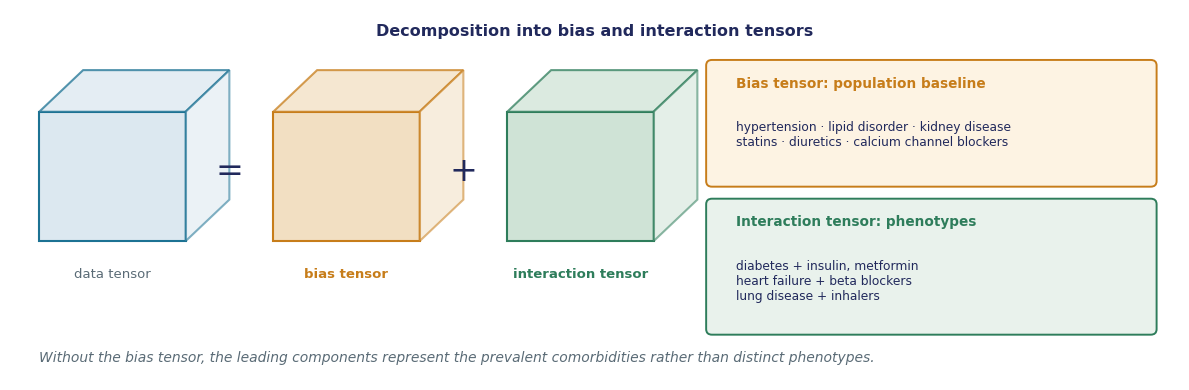

In [ ]:
figure_bias_split()
plt.show()

### Estimation by alternating optimisation

**This part contains `TODO 5`.**

The two terms cannot be estimated simultaneously. They are instead estimated by alternating optimisation:

1. Estimate the bias tensor as a single rank-one component.
2. Subtract it from the data. The residual is the part of the data that the baseline does not explain.
3. Estimate the interaction tensor from this residual.
4. Subtract the interaction tensor from the data, and re-estimate the bias tensor from the resulting residual.
5. Repeat steps 2 to 4 for a fixed number of iterations.

This applies the principle of the multiplicative updates in Part 3 at a higher level: each term is updated while the other is held fixed.

### Rationale

An analogy may clarify the purpose of the decomposition. Consider the task of describing a class photograph in which every pupil wears the same uniform. A description of the photograph as a whole would be dominated by the uniform, as it is the most prevalent feature, and the features that distinguish individual pupils would receive little attention. A more informative description first states that all pupils wear the uniform, and then describes only the features that differ.

| Analogy | Electronic health records |
|---|---|
| The uniform | The **bias tensor**: conditions, such as hypertension, common to almost all patients |
| The distinguishing features | The **interaction tensor**: the patterns that characterise each phenotype |

### Necessity of alternation

The two terms are mutually dependent. An accurate estimate of the baseline requires knowledge of which features belong to the phenotypes, so that they can be excluded; conversely, the phenotypes can be identified only once the baseline is known.

The alternating procedure resolves this dependency iteratively. The initial estimate of the baseline, obtained from the complete data, partially absorbs signal belonging to the phenotypes. Once the phenotypes have been estimated and removed, the baseline can be re-estimated from a residual that is largely free of phenotype signal. Each iteration therefore improves both estimates.

Each blank in `TODO 5` corresponds to one decision in this procedure: the number of components in each term, and the term subtracted at each step.

### Purpose

In the absence of a bias tensor, the dominant pattern in the data determines the leading components. In clinical records this pattern consistently reflects highly prevalent comorbidities. As demonstrated in Part 3, a component is consequently allocated to the baseline and one phenotype is not recovered. The bias tensor accommodates these common conditions explicitly, so that all $R$ components of the interaction tensor are available to represent clinically distinct subgroups.

In [ ]:
def fit_bias_and_interaction(X, R, n_outer=12, n_inner=120, lam_overlap=0.0, seed=0):
    """TODO 5. Estimate the bias and interaction tensors by alternating optimisation.

    Replace each FILL_IN with a number or the name of a variable already
    defined within this function.

    MODEL
    -----
        X  ~  C (bias tensor)  +  T (interaction tensor)

    The bias tensor C is a single rank-one component representing the
    population baseline. The interaction tensor T comprises R components
    representing the phenotypes.

    The two terms are estimated alternately: the interaction tensor is fitted
    to the residual after the bias is removed, and the bias tensor is then
    re-fitted to the residual after the interaction tensor is removed. Each
    iteration refines both estimates.

    np.maximum(..., 0) sets negative residuals to zero, since record counts
    are non-negative.
    """
    # initial estimate of the bias tensor: how many components?
    bias = ncp(X, FILL_IN, n_iter=n_inner, seed=seed)
    inter = None

    for _ in range(n_outer):
        # residual after removing the current bias estimate
        left_over = np.maximum(X - reconstruct(FILL_IN), 0)
        # fit the interaction tensor to this residual: how many components?
        inter = ncp(left_over, FILL_IN, n_iter=n_inner,
                    lam_overlap=lam_overlap, seed=seed)

        # residual after removing the current interaction estimate
        left_over = np.maximum(X - reconstruct(FILL_IN), 0)
        # re-estimate the bias tensor from this residual: how many components?
        bias = ncp(left_over, FILL_IN, n_iter=n_inner, seed=seed)

    return bias, inter


bias, interaction = fit_bias_and_interaction(X, R=4, seed=0)

print("BIAS TENSOR C (population baseline)")
print("   diagnoses  :", top_items(bias[1][:, 0], DIAGNOSES))
print("   medications:", top_items(bias[2][:, 0], MEDICATIONS))
print()
print("INTERACTION TENSOR T (four components)\n")
for r in range(4):
    print(f"component {r}")
    print("   diagnoses  :", top_items(interaction[1][:, r], DIAGNOSES))
    print("   medications:", top_items(interaction[2][:, r], MEDICATIONS))
    print()

**Verify `TODO 5`, then verify all functions together.**

`check_all()` must report **5 of 5 finished** before proceeding. Otherwise the remainder of the notebook will produce results that appear plausible but are incorrect.

In [ ]:
test_fit()
print()
check_all()

The bias tensor now accounts for the common conditions, and each of the four components of the interaction tensor corresponds to a planted phenotype.

The cell below compares the two analyses directly.

### Concept question 3

Suppose that **every patient** in the dataset had a diagnosis of asthma.

**In which part of the model would asthma be represented?**

- **a)** In the bias tensor, since a phenotype represents what distinguishes a subgroup from the population.
- **b)** In a dedicated phenotype, since asthma is a genuine clinical condition.
- **c)** In neither, since a feature common to all patients carries no information.

In [ ]:
concept("q3", "?")

In [ ]:
before = report(diagnoses_f, medications_f, "Standard factorization (no bias tensor)")
after  = report(interaction[1], interaction[2], "With bias tensor")

print(f"phenotypes recovered: {len(before)} without the bias tensor, {len(after)} with it")

### Graphical comparison

Each panel below represents one component. The bars show the weights assigned to diagnoses in that component, in descending order.

**Upper row (without the bias tensor).** One component is absorbed by the population baseline and does not correspond to a phenotype.

**Lower row (with the bias tensor).** The bias tensor, shown in orange, accounts for the common conditions, and each of the four components of the interaction tensor corresponds to a planted phenotype.

In [ ]:
compare_pieces(diagnoses_f, bias[1], interaction[1], DIAGNOSES)
plt.show()

### Convergence of the bias tensor

The figure below traces the weights of selected diagnoses in the bias tensor across iterations of the alternating procedure implemented in `TODO 5`.

The left panel shows two highly prevalent conditions. Their weights remain high throughout, as is expected of features of the population baseline.

The right panel shows two diagnoses that belong to phenotypes. At iteration 0 the bias tensor assigns them small but non-zero weight, having been estimated before the phenotypes were known. After a single iteration these weights decrease by more than half, indicating that phenotype signal has been transferred from the bias tensor to the interaction tensor.

The absolute magnitudes in the right panel are small; the relevant observation is their decrease.

In [ ]:
show_baseline_rounds(X, R=4, labels=DIAGNOSES)
plt.show()

---
# 5. Sparsity and interpretability

The factor vectors produced by the decomposition are dense: every diagnosis receives a non-zero weight in every component, however small.

The cell below displays the complete diagnosis vector of one component.

In [ ]:
r = 0
col = interaction[1][:, r]
order = col.argsort()[::-1]

print(f"component {r}: weight of every diagnosis\n")
for i in order:
    bar = "#" * int(60 * col[i] / col.max())
    print(f"  {DIAGNOSES[i]:28s} {col[i]:.4f}  {bar}")

Three entries are large and the remainder are small but non-zero, which renders a complete listing difficult to interpret.

Rubik addresses this with a sparsity constraint, setting entries below a threshold to zero, with separate thresholds for the patient, diagnosis and medication modes.

This assignment uses a simplified rule: an entry is retained only if it is at least a fraction `gamma` of the largest entry in its vector. The threshold is therefore relative rather than absolute.

The cell below shows the effect of varying `gamma`.

In [ ]:
for gamma in [0.02, 0.10, 0.20, 0.40, 0.70]:
    items = top_items(interaction[1][:, 0], DIAGNOSES, gamma=gamma)
    print(f"  gamma = {gamma:.2f}: {len(items)} diagnoses retained: {items}")

### Graphical representation of the threshold

The dashed line marks the threshold. Entries below it, shown in grey, are set to zero; entries above it are retained. The left and right panels apply `gamma` = 0.15 and `gamma` = 0.5 respectively to the same component.

In [ ]:
show_cutoff(interaction[1][:, 0], DIAGNOSES, gammas=(0.15, 0.5))
plt.show()

A low value of `gamma` retains entries of negligible weight, whereas a high value discards genuine features of the phenotype. There is no uniquely correct value. The choice reflects a trade-off between completeness and interpretability, and the value used should be reported alongside any result.

### Concept question 4

**What is the effect of setting `gamma = 1.0`?**

- **a)** The vector is unchanged.
- **b)** All entries are retained.
- **c)** Only the largest entry in each vector is retained.

In [ ]:
concept("q4", "?")

---
# 6. Diversity of phenotypes

The analyses so far have used four components, matching the number of planted phenotypes. In practice the number of phenotypes is unknown and must be specified in advance; it is commonly overestimated in order to avoid missing structure.

The cell below fits six components to data containing four phenotypes.

In [ ]:
bias6, inter6 = fit_bias_and_interaction(X, R=6, seed=1)

print("R = 6 COMPONENTS, FOUR PLANTED PHENOTYPES\n")
for r in range(6):
    print(f"component {r}")
    print("   diagnoses  :", top_items(inter6[1][:, r], DIAGNOSES))
    print("   medications:", top_items(inter6[2][:, r], MEDICATIONS))
    print()

Several components are now near-duplicates, sharing most of their diagnoses.

Such redundancy impairs interpretation. A set of six phenotypes of which two are nearly identical represents only five distinct findings, and leaves the reader to identify the duplication.

### Measurement of overlap

Redundancy is quantified by the **cosine similarity** between the diagnosis vectors of each pair of components, which equals 1 for vectors of identical direction and 0 for vectors with no shared entries. The mean over all pairs is reported as **AvgOverlap**, following the paper.

### Concept question 5

Two components contain **identical** diagnoses with identical weights.

**What value does `avg_overlap` return for this pair?**

- **a)** 0.0
- **b)** 1.0
- **c)** A value that depends on the magnitude of the weights.

In [ ]:
concept("q5", "?")

In [ ]:
print("AvgOverlap, R = 4:", round(avg_overlap(interaction[1]), 3))
print("AvgOverlap, R = 6:", round(avg_overlap(inter6[1]), 3))
print("\nOverestimating R increases overlap between components.")

### Enforcing diversity

**This part applies `TODO 4`, defined in the `ncp` cell in Part 3.**

Rubik adds to the objective a penalty term that favours mutually dissimilar components. Its weight, denoted $\lambda_q$ in the paper and `lam_overlap` in the code, controls the strength of this preference: larger values yield more distinct components.

The cell below fits the model over a range of values of $\lambda$.

In [ ]:
import time
results = []
for lam in [0, 0.5, 1, 2, 5, 10, 20, 50]:
    b, inter_l = fit_bias_and_interaction(X, R=6, lam_overlap=lam, seed=1)
    ov = avg_overlap(inter_l[1])
    found = {m[1] for m in match_to_truth(inter_l[1], inter_l[2]) if m[2] >= 0.7}
    results.append((lam, ov, len(found)))
    print(f"  lambda = {lam:5.1f}   average overlap = {ov:.3f}   "
          f"phenotypes recovered = {len(found)}/4")

Overlap decreases as $\lambda$ increases, and all four planted phenotypes are retained.

The figure below illustrates the notion of overlap (left) and plots the observed relationship (right), which reproduces the qualitative behaviour reported in the paper.

In [ ]:
figure_overlap([(l, o) for l, o, _ in results])
plt.show()

### Pairwise similarity between components

The figure below decomposes the overlap score into its pairwise constituents. Each cell gives the cosine similarity between two components, with darker cells indicating greater similarity. Diagonal cells compare each component with itself and are necessarily equal to 1; the informative values lie off the diagonal.

Without the penalty (left), one off-diagonal pair has a similarity close to 1, identifying two near-duplicate components. With the penalty (right), the similarity of this pair is substantially reduced.

In [ ]:
_, pieces_no_push = fit_bias_and_interaction(X, R=6, seed=1)
_, pieces_pushed  = fit_bias_and_interaction(X, R=6, lam_overlap=20, seed=1)
show_similarity(pieces_no_push[1], pieces_pushed[1], lam=20)
plt.show()

A lower overlap should not be equated with a more accurate result. A sufficiently large $\lambda$ will separate components even where the underlying phenotypes genuinely share features, and in these data two phenotypes do share chronic kidney disease and ACE inhibitors.

The penalty improves interpretability; it does not, in itself, improve validity.

### Concept question 6

Two of the planted phenotypes genuinely share chronic kidney disease.

**What does a very low overlap score indicate about the correctness of the recovered phenotypes?**

- **a)** That they are correct, since the phenotypes are clearly separated.
- **b)** That they are incorrect, since low overlap is undesirable.
- **c)** Nothing in itself: phenotypes may genuinely share features, and enforcing separation may conceal true structure.

In [ ]:
concept("q6", "?")

---
# 7. Robustness to missing records

Clinical records are incomplete: encounters may go uncoded, prescriptions may be issued by other providers, and patients may transfer between institutions.

Robustness to incompleteness is assessed by deleting a random proportion of the recorded entries and refitting the model. Because the deletion is random, three independent replicates are performed at each level.

In [ ]:
import numpy as np

# Deletion is random, so a single replicate may be unrepresentative.
# Three independent replicates are performed at each level.
print("Random deletion of records, three replicates per level\n")
missing_results = []
for p in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6]:
    tries = []
    for t in range(3):
        rng = np.random.default_rng(100 * t + int(p * 100))
        Xm = X.copy()
        present = np.argwhere(Xm > 0)
        drop = present[rng.random(len(present)) < p]
        Xm[tuple(drop.T)] = 0
        b, inter_m = fit_bias_and_interaction(Xm, R=4, seed=1)
        found = {m[1] for m in match_to_truth(inter_m[1], inter_m[2]) if m[2] >= 0.7}
        tries.append(len(found))
    missing_results.append((p, tries))
    print(f"  {int(p*100):3d}% deleted: phenotypes recovered per replicate = {tries}")

### Graphical summary

The line shows the mean number of phenotypes recovered across the three replicates; the shaded band spans the minimum and maximum.

The replicates do not always agree. A single replicate would not allow a genuine decline in performance to be distinguished from random variation, which is why replication is necessary.

In [ ]:
show_missing(missing_results)
plt.show()

Recovery is maintained at low levels of deletion and deteriorates as the proportion of missing records increases.

This analysis bears on the evaluation of published phenotyping methods. A result that persists under substantial data loss is more credible than one that does not, and the test requires little additional computation.

### Concept question 7

**Why does the deletion of records affect a small phenotype more than a large one?**

- **a)** Because small phenotypes involve rarer conditions, which the method disregards.
- **b)** Because a small phenotype is supported by fewer records, so the removal of the same proportion leaves less evidence for it.
- **c)** It does not; all phenotypes are affected equally.

In [ ]:
concept("q7", "?")

---
# 8. Annotation of phenotypes by a language model

The recovered phenotypes are lists of diagnoses and medications, which still require interpretation.

In the original study, interpretation was performed by clinicians. Three physicians independently rated thirty phenotypes produced by each method, blinded to the method of origin, as clinically meaningful, possibly meaningful or not meaningful. Inter-rater agreement was high, and 65% of the Rubik phenotypes were rated clinically meaningful, compared with 31% for the preceding method.

Expert review of this kind is rigorous but does not scale to large numbers of phenotypes. This motivates the question of whether a language model could perform part of the task.

### Appropriate and inappropriate uses

**Appropriate.** Assigning a descriptive label to a phenotype on the basis of its diagnoses and medications. This is a linguistic task, and its output can be verified against the planted phenotypes.

**Inappropriate without external grounding.** Determining whether a medication is an accepted treatment for a diagnosis. A language model answers such questions from its training data, confidently and occasionally incorrectly. The model is therefore required to consult a lookup table.

**Not yet validated.** Judging whether a phenotype is clinically meaningful. No ground truth exists against which such judgements could be checked; establishing their reliability would require demonstrating agreement with human raters, as measured in the original study.

The tools defined below address the first two uses. The third is the subject of a written question.

In [ ]:
!pip install -q -U transformers accelerate 2>&1 | tail -3

import torch
assert torch.cuda.is_available(), "Runtime -> Change runtime type -> T4 GPU"

from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL = "Qwen/Qwen3-4B-Instruct-2507"      # or "Qwen/Qwen3-1.7B" if slow
tokenizer = AutoTokenizer.from_pretrained(MODEL)
model = AutoModelForCausalLM.from_pretrained(
    MODEL, torch_dtype=torch.float16, device_map="cuda")    # T4 needs float16
model.eval()
print("loaded", MODEL)

### Overview of the experimental design

The figure below summarises Part 8. Each recovered phenotype is presented to the same language model under two conditions.

In **Condition A**, the model has access to two tools: one that returns the phenotype, and one that checks a medication–diagnosis pair against a lookup table. Each claim about a drug indication is therefore verified at the moment it is made, and the model's final answer is produced only after all tool calls have returned.

In **Condition B**, the model answers from its training data alone. Its claims are not checked when they are made; instead they are audited against the same lookup table afterwards.

Because the model and the phenotypes are identical in the two conditions, any difference between the outputs is attributable to access to external knowledge. Written question 5 asks for this comparison.

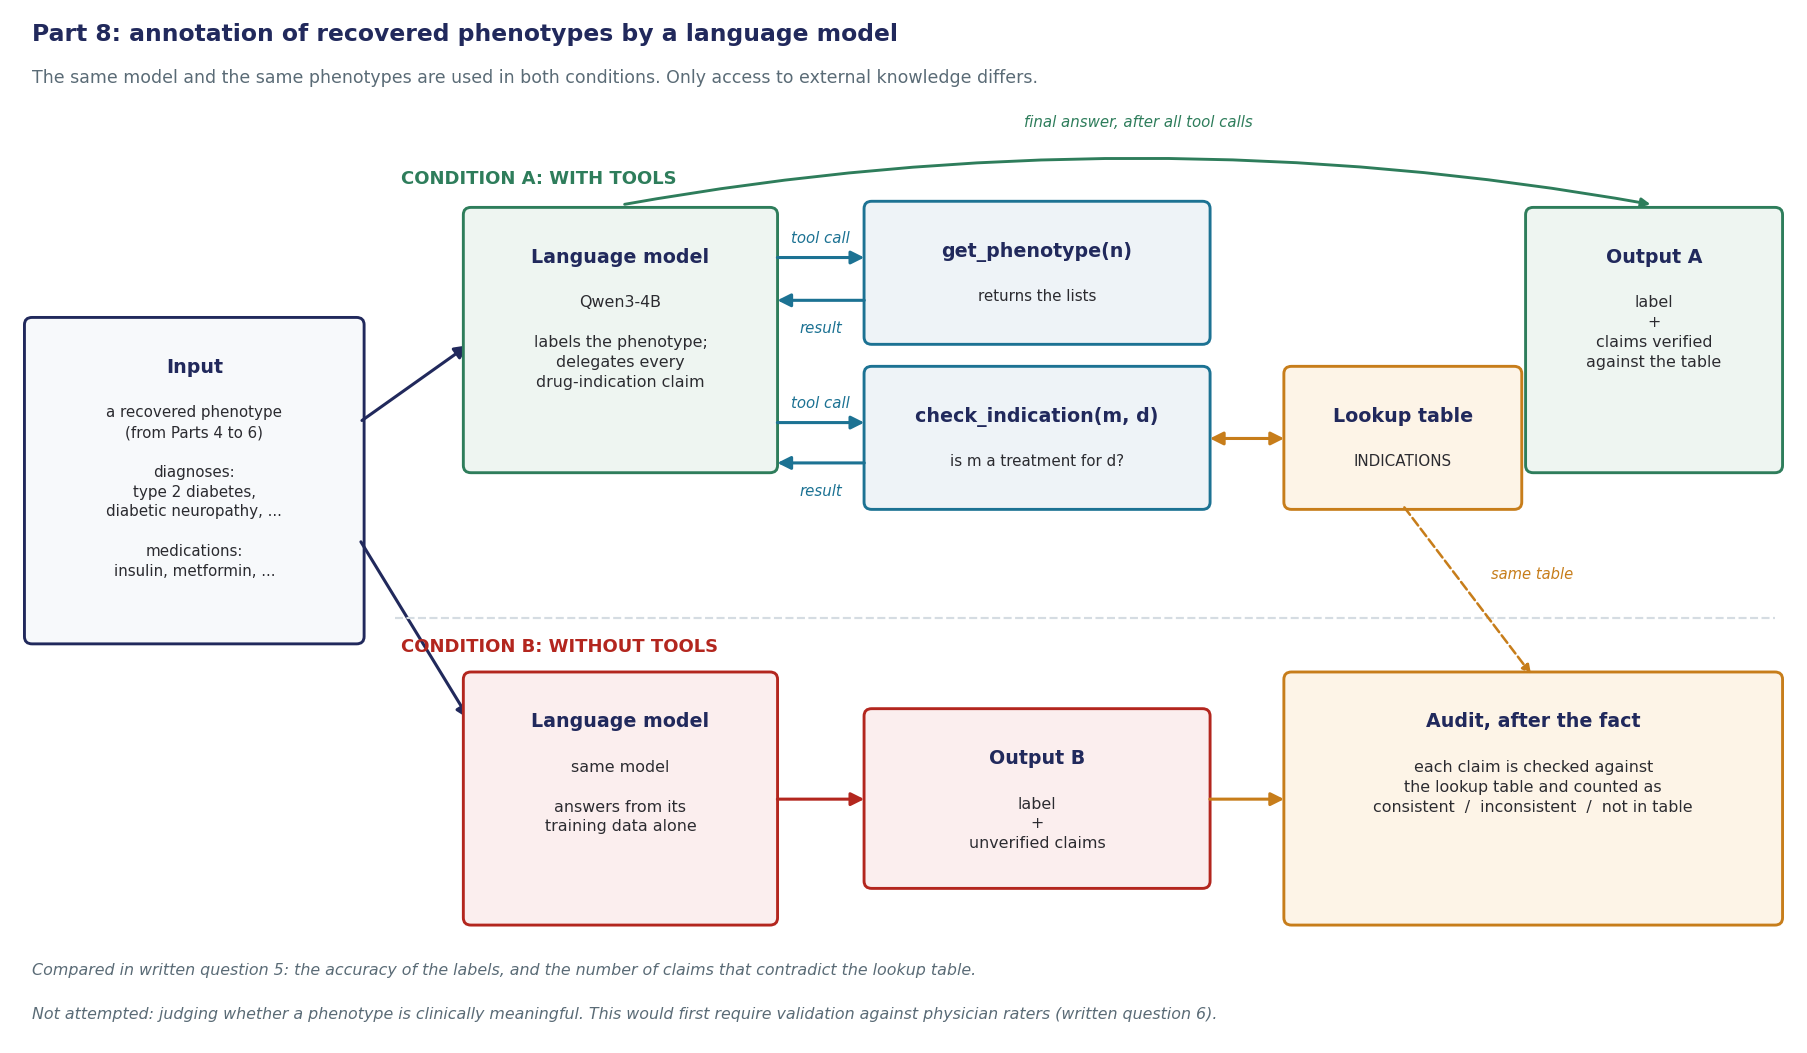

The lookup table below specifies which drug classes are accepted treatments for which diagnoses. It is deliberately limited in scope. Any pair not listed is treated as unknown, and the tool reports it as such rather than inferring an answer.

In [ ]:
INDICATIONS = {
 ("metformin", "type 2 diabetes"): True,
 ("insulin", "type 2 diabetes"): True,
 ("SGLT2 inhibitors", "type 2 diabetes"): True,
 ("SGLT2 inhibitors", "heart failure"): True,
 ("SGLT2 inhibitors", "chronic kidney disease"): True,
 ("ACE inhibitors", "chronic kidney disease"): True,
 ("ACE inhibitors", "heart failure"): True,
 ("ACE inhibitors", "hypertension"): True,
 ("beta blockers", "heart failure"): True,
 ("beta blockers", "atrial fibrillation"): True,
 ("anticoagulants", "atrial fibrillation"): True,
 ("loop diuretics", "heart failure"): True,
 ("statins", "lipid disorder"): True,
 ("calcium channel blockers", "hypertension"): True,
 ("inhaled steroids", "asthma"): True,
 ("inhaled steroids", "COPD"): True,
 ("bronchodilators", "asthma"): True,
 ("bronchodilators", "COPD"): True,
 ("antibiotics", "chest infection"): True,
 ("SSRIs", "depression"): True,
 ("SSRIs", "anxiety"): True,
 ("benzodiazepines", "anxiety"): True,
 ("benzodiazepines", "insomnia"): True,
 # deliberately recorded as NOT an accepted use
 ("metformin", "heart failure"): False,
 ("beta blockers", "asthma"): False,
 ("SSRIs", "insomnia"): False,
}

CURRENT = {}          # the phenotype the model is allowed to ask about


def get_phenotype(number: int) -> dict:
    """Return the diagnoses and medications of one discovered phenotype.

    Args:
        number: Which phenotype to look at, counting from 0.
    """
    if number not in CURRENT:
        raise ValueError(f"no phenotype numbered {number}. "
                         f"Available: {sorted(CURRENT)}")
    return CURRENT[number]


def check_indication(medication: str, diagnosis: str) -> dict:
    """Check whether a medication is an accepted treatment for a diagnosis.

    Args:
        medication: The medication class, exactly as written in the phenotype.
        diagnosis: The diagnosis, exactly as written in the phenotype.
    """
    key = (medication.strip(), diagnosis.strip())
    if key not in INDICATIONS:
        raise ValueError(
            f"'{medication}' for '{diagnosis}' is not in the indication table. "
            f"That means it is unknown here, not that it is wrong. "
            f"Do not answer from memory.")
    return {"medication": medication, "diagnosis": diagnosis,
            "accepted_treatment": INDICATIONS[key]}


print(f"{len(INDICATIONS)} indication records loaded")

In [ ]:
import json, re

def ask_model(messages, tools, max_new_tokens=350):
    text = tokenizer.apply_chat_template(
        messages, tools=tools, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return tokenizer.decode(out[0][inputs.input_ids.shape[1]:],
                            skip_special_tokens=True).strip()


def parse_tool_calls(text):
    calls = []
    for blob in re.findall(r"<tool_call>\s*(.*?)\s*</tool_call>", text, re.S):
        try:
            calls.append(json.loads(blob))
        except json.JSONDecodeError:
            pass
    return calls


def run(question, tools, max_turns=14, verbose=True):
    by_name = {f.__name__: f for f in tools}
    messages = [{"role": "user", "content": question}]
    used = []
    for turn in range(max_turns):
        reply = ask_model(messages, tools)
        calls = parse_tool_calls(reply)
        if not calls:
            return {"answer": reply, "tools_used": used}
        messages.append({"role": "assistant", "content": reply})
        for call in calls:
            name, args = call.get("name"), call.get("arguments", {})
            used.append({"tool": name, "args": args})
            try:
                result = {"result": by_name[name](**args)}
            except KeyError:
                result = {"error": f"no such tool: {name}"}
            except Exception as e:
                result = {"error": str(e)}
            if verbose:
                print(f"   {name}({args}) -> {str(result)[:95]}")
            messages.append({"role": "tool",
                             "content": json.dumps(result, default=str)})
    return {"answer": None, "tools_used": used, "note": "ran out of turns"}

print("Helper functions loaded.")

The model is now given each recovered phenotype and asked to label it and to verify its medications using the lookup tool.

In [ ]:
GAMMA = 0.15
CURRENT.clear()
for r in range(4):
    CURRENT[r] = {
        "phenotype": r,
        "diagnoses": top_items(interaction[1][:, r], DIAGNOSES, GAMMA),
        "medications": top_items(interaction[2][:, r], MEDICATIONS, GAMMA),
    }

TOOLS = [get_phenotype, check_indication]
answers_with_tools = {}

for r in range(4):
    print("=" * 72)
    print(f"PHENOTYPE {r}: {CURRENT[r]['diagnoses']} + {CURRENT[r]['medications']}")
    q = (f"Look at phenotype {r}. Say in one sentence what patient group it "
         f"describes. Then check each medication against each diagnosis using "
         f"the indication tool, and report anything that is not an accepted "
         f"treatment or is not in the table.")
    out = run(q, TOOLS)
    answers_with_tools[r] = out
    print("\nMODEL:", (out["answer"] or "(no response)")[:500])
    print()

### The same task without tools

For comparison, the model is now asked to perform the task from its own knowledge, without access to the lookup table. This corresponds to typical unassisted use.

In [ ]:
answers_no_tools = {}

for r in range(4):
    p = CURRENT[r]
    q = (f"A group of patients has these diagnoses: {p['diagnoses']}. "
         f"They take these medications: {p['medications']}. "
         f"Name the patient group in one sentence, then state whether each "
         f"medication is an accepted treatment for each diagnosis.")
    out = ask_model([{"role": "user", "content": q}], tools=[])
    answers_no_tools[r] = out
    print("=" * 72)
    print(f"PHENOTYPE {r}")
    print(out[:500], "\n")

### Assessment of unsupported claims

The responses produced without tools contain assertions about which medications treat which conditions, some of which can be checked against the lookup table.

The cell below extracts each medication–diagnosis pair mentioned in these responses and classifies it as consistent with the table, inconsistent with the table, or absent from the table.

This procedure is approximate, since the extraction of claims from free text is imperfect. A sample of the responses should be read directly before the counts are relied upon.

In [ ]:
def audit_free_text(text, phenotype):
    supported = contradicted = unknown = 0
    for med in phenotype["medications"]:
        for dx in phenotype["diagnoses"]:
            if med.lower() in text.lower() and dx.lower() in text.lower():
                key = (med, dx)
                if key not in INDICATIONS:
                    unknown += 1
                elif INDICATIONS[key]:
                    supported += 1
                else:
                    contradicted += 1
    return supported, contradicted, unknown

print("Medication-diagnosis pairs in the unassisted responses, checked against the table\n")
tot = [0, 0, 0]
for r in range(4):
    s, c, u = audit_free_text(answers_no_tools[r], CURRENT[r])
    tot = [tot[0]+s, tot[1]+c, tot[2]+u]
    print(f"  phenotype {r}: {s} are consistent with the table, {c} are inconsistent with it, "
          f"{u} are not in the table")
print(f"\n  total: {tot[0]} consistent, {tot[1]} inconsistent, {tot[2]} not in table")
print("\nThe second figure is the most consequential: it counts claims that")
print("contradict the table and were made without any check.")

---
# 9. Written questions

The concept questions provided brief checks of understanding. The following questions require extended written answers.

Answers should be entered in a text cell at the end of the notebook, with three to four sentences for each question.

**Answers must report the results actually obtained, not the results expected.** Any unexpected behaviour, including that of the language model, should be described as observed.

**Question 1.**
In Part 3 the standard factorization allocated a component to the population baseline. Explain why the baseline constituted the dominant pattern in the data despite being the least informative.

**Question 2.**
Select a value of `gamma` suitable for presenting these phenotypes to a clinician. Report the resulting lists and justify the choice. Discuss what is lost, and what is gained, at a higher value.

**Question 3.**
In Part 6 overlap decreased as $\lambda$ increased. Two of the planted phenotypes genuinely share chronic kidney disease and ACE inhibitors. Explain why a low overlap score is therefore not equivalent to a correct result.

**Question 4.**
In Part 7 phenotypes were lost as the proportion of deleted records increased. Identify the phenotype that was lost first and propose an explanation.

**Question 5.**
Compare the language model's responses with and without access to tools. Assess whether the phenotypes were labelled correctly in each condition, and whether the tool-assisted condition identified errors present in the unassisted condition. Quote one example.

**Question 6.**
The original study relied on ratings by three physicians, who exhibited high mutual agreement. Suppose that one of these raters were to be replaced by a language model. Describe the study that should be conducted first, and specify the result that would justify the replacement.

---
# 10. Submission

Submit **a single file**: this notebook, executed in full from top to bottom with all output visible, and containing the answers to the six written questions in a final cell.

### Assessment (100 points)

| Component | Points |
|---|---|
| `TODO 1` reconstruct: all tests pass | 8 |
| `TODO 2` sparsify and top_items: all tests pass | 8 |
| `TODO 3` avg_overlap: all tests pass | 8 |
| `TODO 4` overlap_penalty: all tests pass | 8 |
| `TODO 5` fit_bias_and_interaction: all tests pass | 13 |
| The seven concept questions | 7 |
| Parts 1 to 8 executed, with output visible | 8 |
| Question 1: dominance of the baseline | 6 |
| Question 2: choice and justification of `gamma`, with lists reported | 8 |
| Question 3: distinction between low overlap and correctness | 8 |
| Question 4: identification and explanation of the first phenotype lost | 6 |
| Question 5: comparison of the two model conditions, with a quoted example | 8 |
| Question 6: study design and acceptance criterion | 4 |

`check_all()` must report **5 of 5 finished** in the submitted notebook. A function that fails its tests receives no credit for that item, irrespective of how closely it approaches a correct solution.

**Answers receiving no credit.**

An answer to Question 3 asserting that lower overlap is simply preferable receives no credit for that item. Part 6 is intended to demonstrate that a constraint which improves interpretability may also conceal genuine structure.

An answer to Question 6 proposing that a language model could replace a clinician without validation receives no credit. The original study measured agreement among human raters; the answer must specify what would be measured.

### Troubleshooting

| Problem | Resolution |
|---|---|
| A test reports an outstanding `FILL_IN` | Complete the remaining blank in the indicated function. |
| Every phenotype is reported as "no planted phenotype matches" | `top_items` is retaining entries that should be discarded. Execute `test_sparsify()`. |
| "No GPU" in Part 8 | Select Runtime → Change runtime type → T4 GPU, then execute the notebook from the beginning. |
| Insufficient memory | Select Runtime → Restart session and execute the notebook from the beginning, loading the model only once. |
| Slow model download | Substitute `Qwen/Qwen3-1.7B` and state this in the submission. |
| Components differ between runs | The algorithm is initialised randomly, so the order of components is not fixed. The `seed` may be changed. |
| The model does not invoke any tool | Review the tool descriptions, which constitute the only information available to the model about each tool. |

### Glossary

| Term | Definition |
|---|---|
| **Phenotype** | A clinically coherent subgroup of patients characterised by shared diagnoses and medications |
| **Tensor** | A multidimensional array; here, of order three |
| **Mode** | One dimension of a tensor: patient, diagnosis or medication |
| **Order** | The number of indices required to identify an entry of a tensor |
| **Rank-one tensor** | The outer product of one vector per mode |
| **CP decomposition** | The approximation of a tensor as a sum of rank-one tensors |
| **R** | The number of components in the decomposition |
| **Factor matrix** | The vectors of one mode across all components, arranged as columns |
| **Non-negativity** | The constraint that all factor entries be non-negative, so that phenotypes are defined by the presence of features |
| **Bias tensor** | The rank-one term representing the population baseline |
| **Interaction tensor** | The sum of the $R$ components representing the phenotypes |
| **Sparsity** | The setting of small entries to zero in order to improve interpretability |
| **gamma** | The sparsity threshold, expressed as a fraction of the largest entry in a vector |
| **Cosine similarity** | A measure of the similarity in direction of two vectors |
| **AvgOverlap** | The mean cosine similarity over all pairs of components |
| **lambda** | The weight of the penalty favouring mutually dissimilar components |